In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# from xgboost import XGBRegressor 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None) 
pd.set_option('display.max_rows', 100) 

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

np.random.seed(42)


In [3]:
import matplotlib.font_manager as fm

plt.style.use('seaborn-v0_8-whitegrid')
font_path = "C:/Windows/Fonts/malgun.ttf"
font = fm.FontProperties(fname=font_path).get_name()

plt.rcParams['font.family'] = font
plt.rcParams['axes.unicode_minus'] = False


In [4]:
# 데이터 로드 & 정제

all = pd.read_csv('../data/olist_preprocess_ver2_data.csv')
df= all.copy()
# print(df.shape[0], 'rows × ', df.shape[1], 'columns')
# 111495 rows ×  29 columns

# 날짜 칼럼 변환
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date',
    'review_creation_date'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df = df[
    (df['order_delivered_customer_date'] != pd.Timestamp('2099-01-01')) &  #두 조건 동일행 의미
    (df['order_status'] == 'delivered')
]
# removed rows: 1881
# remaining rows: 10961

In [5]:
# 배송 지연 계산 (핵심 타겟)
# 배송 지연 일수 계산
df['delivery_delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['is_delayed'] = (df['delivery_delay_days'] > 0).astype(int)

# 결측치 제거 (핵심 칼럼만)
df_analysis = df.copy()
df = df[['delivery_delay_days', 'is_delayed', 'review_score']].dropna()

# print(len(df), "rows")
# print(f"{df['delivery_delay_days'].mean():.2f}, {df['delivery_delay_days'].median():.2f}, {df['delivery_delay_days'].min():.0f}, {df['delivery_delay_days'].max():.0f}, {df['delivery_delay_days'].std():.2f}, {df['is_delayed'].mean()*100:.1f}%)
# print(f"{df['review_score'].mean():.2f}, {df['review_score'].median():.0f}점, {df['review_score'].min():.0f}~{df['review_score'].max():.0f})

#======================================================================================
# 결과
# 배송 지연 통계:
#    - 평균 지연: -12.05일
#    - 중앙값: -13.00일
#    - 최소값: -147일
#    - 최대값: 188일
#    - 표준편차: 10.10일
#    - 지연 발생률: 6.5%

# 고객 만족도 통계:
#    - 평균: 4.08점
#    - 중앙값: 5점
#    - 범위: 1~5점

In [6]:
# # 이상치 확인
# print(f"- 100일 지연: {(df['delivery_delay_days'] > 100).sum():,}개")
# print(f"- 음수(조기배송): {(df['delivery_delay_days'] < 0).sum():,}개") #정제 
# print(f"- 0(정일배송): {(df['delivery_delay_days'] == 0).sum():,}개") #정제

#======================================================================================
# 결과
# - 100일 지연: 41개
# - 음수(조기배송): 100,283개
# - 0(정일배송): 1,433개

In [7]:
# 분석 목적에 맞게 필터
# 지연 1일이상
df_not_filter = df.copy()
df = df[
    (df['delivery_delay_days'] > 0) & 
    # (df['delivery_delay_days'] <= 100) &
    (df['review_score'].notna())
].copy()

# print(f"   원본: {len(df_not_filter):,}개")
# print(f"   필터링 후: {len(df):,}개 (이상치 {len(df_not_filter)-len(df):,}개 제거)")

#======================================================================================
# 결과
# 원본: 108,790개
# 필터링 후: 7,074개 (데이터 정제로 분석 목적에 해당하지 않는 행 101,716개 제거)

In [8]:
# # 필터링된 데이터 통계
# print(f"{df['delivery_delay_days'].mean():.2f}")
# print(f"{df['delivery_delay_days'].median():.2f}")
# print(f"{df['delivery_delay_days'].min():.0f}")
# print(f"{df['delivery_delay_days'].max():.0f}")
# print(f"{df['delivery_delay_days'].std():.2f}")
# print(f"{df['is_delayed'].mean()*100:.1f}%")

#======================================================================================
# 결과
# 필터링된 데이터 통계:

# 배송 지연:
#    평균: 10.39일
#    중앙값: 7.00일
#    최소값: 1일
#    최대값: 188일
#    표준편차: 14.34일
#    지연 발생률: 100.0%

# 고객 만족도:
#    평균: 2.26점
#    중앙값: 1점
#    표준편차: 1.57점

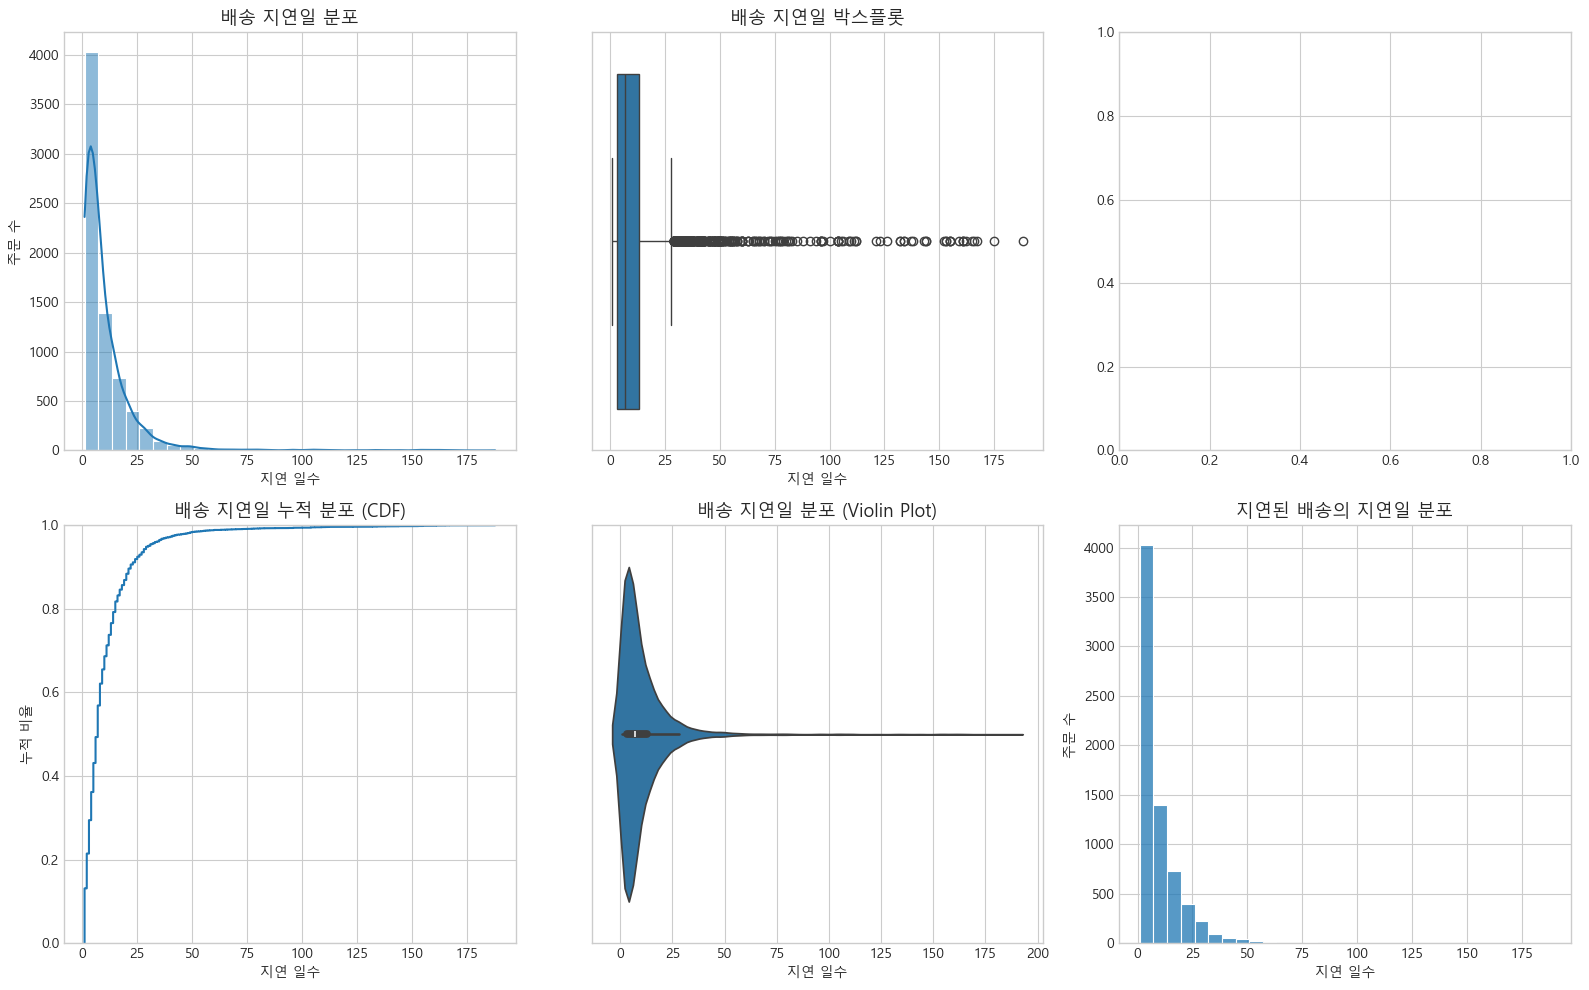

In [9]:
#시각화 확인

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 배송 지연일 분포
sns.histplot(df['delivery_delay_days'], bins=30, kde=True, ax=axes[0,0])
axes[0,0].set_title("배송 지연일 분포", fontsize=13)
axes[0,0].set_xlabel("지연 일수")
axes[0,0].set_ylabel("주문 수")

# 박스플롯 (이상치 확인)
sns.boxplot(x=df['delivery_delay_days'], ax=axes[0,1])
axes[0,1].set_title("배송 지연일 박스플롯", fontsize=13)
axes[0,1].set_xlabel("지연 일수")


# bar 값 표시
for p in axes[0,2].patches:
    axes[0,2].annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

# CDF (누적 분포)
sns.ecdfplot(df['delivery_delay_days'], ax=axes[1,0])
axes[1,0].set_title("배송 지연일 누적 분포 (CDF)", fontsize=13)
axes[1,0].set_xlabel("지연 일수")
axes[1,0].set_ylabel("누적 비율")

# Violin plot
sns.violinplot(x=df['delivery_delay_days'], ax=axes[1,1])
axes[1,1].set_title("배송 지연일 분포 (Violin Plot)", fontsize=13)
axes[1,1].set_xlabel("지연 일수")

# 지연된 배송만 분포
sns.histplot(df[df['is_delayed']==1]['delivery_delay_days'], bins=30, ax=axes[1,2])
axes[1,2].set_title("지연된 배송의 지연일 분포", fontsize=13)
axes[1,2].set_xlabel("지연 일수")
axes[1,2].set_ylabel("주문 수")

plt.tight_layout()
plt.show()

In [10]:
# 합리적 범위로 필터링 (1~75일까지)
df_not_filter = df.copy()
df = df[(df['delivery_delay_days'] <= 75)]

#print(f"원본: {len(df_not_filter):,}개")
#print(f"필터링 후: {len(df):,}개 (이상치 {len(df_not_filter)-len(df):,}개 제거)")

#======================================================================================
# 결과
#   원본: 7,074개
#   필터링 후: 7,012개 (이상치 62개 제거) #0.8%

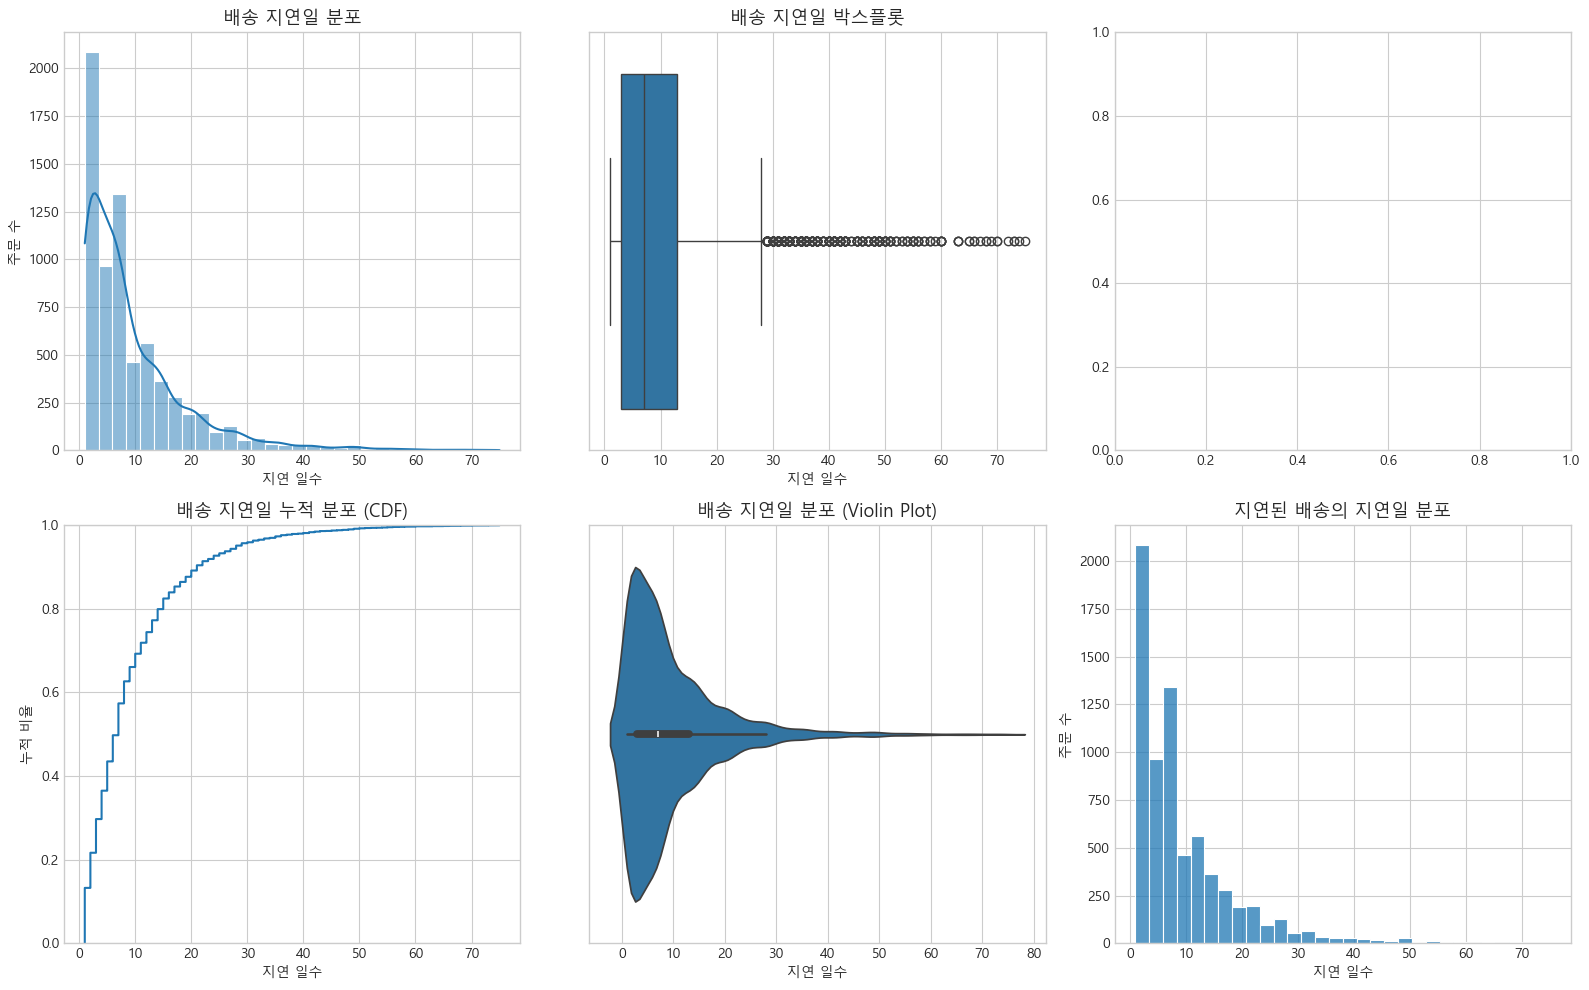

In [11]:
# 극단치 제거 후 시각화 확인

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 배송 지연일 분포
sns.histplot(df['delivery_delay_days'], bins=30, kde=True, ax=axes[0,0])
axes[0,0].set_title("배송 지연일 분포", fontsize=13)
axes[0,0].set_xlabel("지연 일수")
axes[0,0].set_ylabel("주문 수")

# 박스플롯 (이상치 확인)
sns.boxplot(x=df['delivery_delay_days'], ax=axes[0,1])
axes[0,1].set_title("배송 지연일 박스플롯", fontsize=13)
axes[0,1].set_xlabel("지연 일수")


# bar 값 표시
for p in axes[0,2].patches:
    axes[0,2].annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

# CDF (누적 분포)
sns.ecdfplot(df['delivery_delay_days'], ax=axes[1,0])
axes[1,0].set_title("배송 지연일 누적 분포 (CDF)", fontsize=13)
axes[1,0].set_xlabel("지연 일수")
axes[1,0].set_ylabel("누적 비율")

# Violin plot
sns.violinplot(x=df['delivery_delay_days'], ax=axes[1,1])
axes[1,1].set_title("배송 지연일 분포 (Violin Plot)", fontsize=13)
axes[1,1].set_xlabel("지연 일수")

# 지연된 배송만 분포
sns.histplot(df[df['is_delayed']==1]['delivery_delay_days'], bins=30, ax=axes[1,2])
axes[1,2].set_title("지연된 배송의 지연일 분포", fontsize=13)
axes[1,2].set_xlabel("지연 일수")
axes[1,2].set_ylabel("주문 수")

plt.tight_layout()
plt.show()

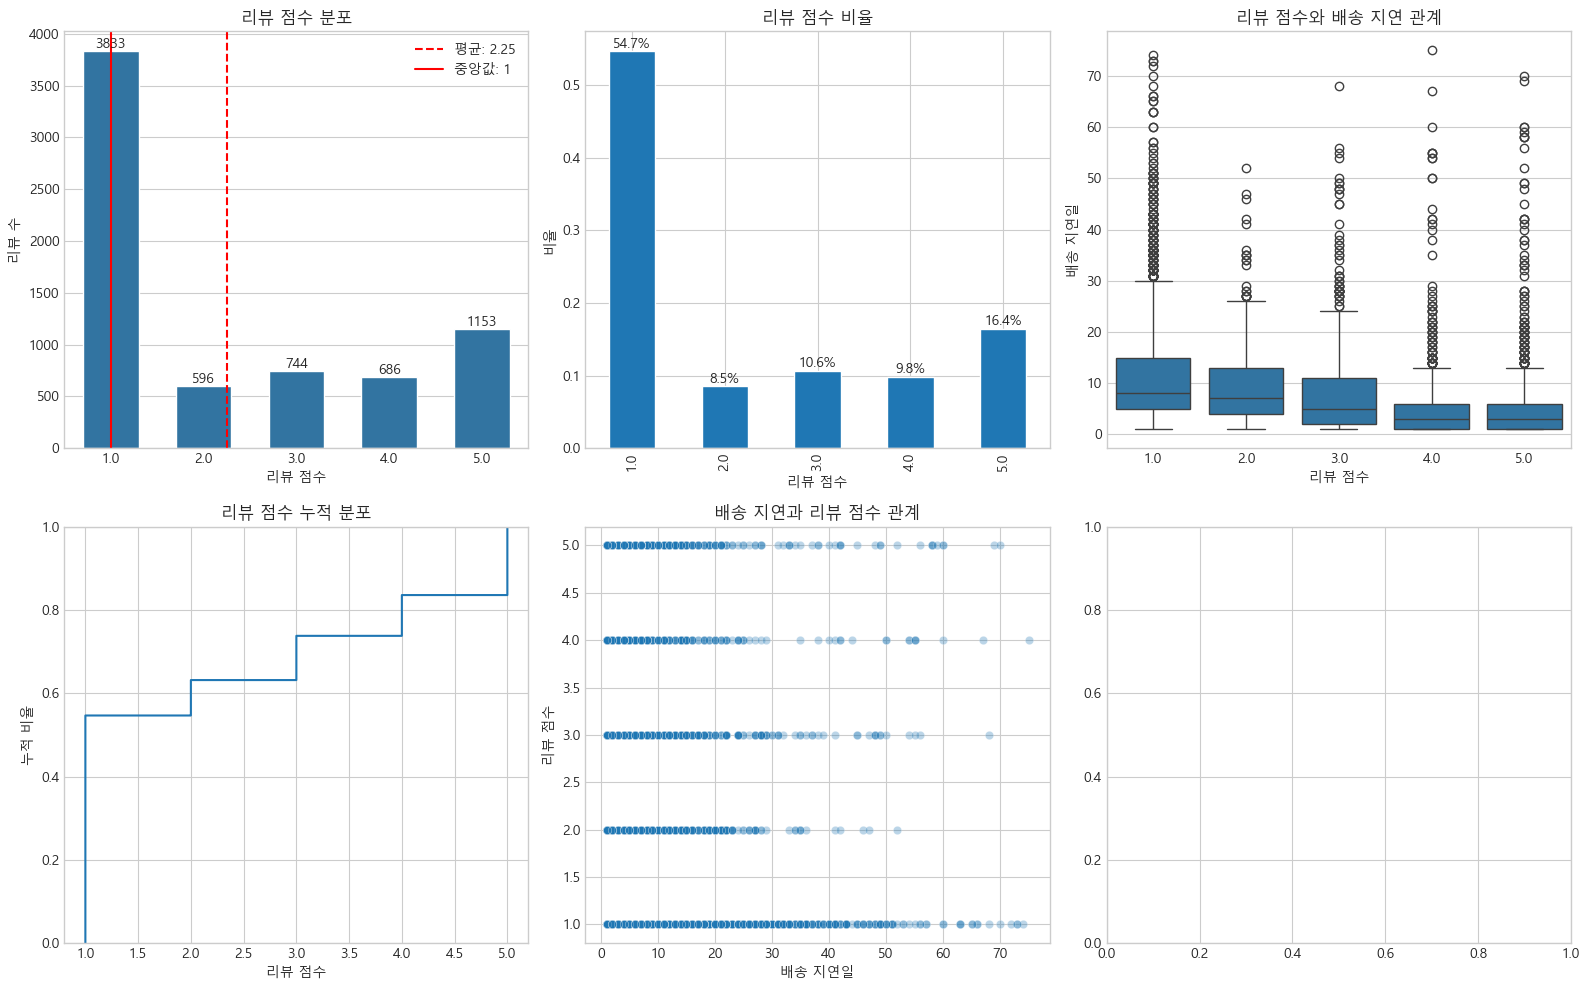

In [12]:
#리뷰 분포

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. 리뷰 점수 분포
mean_score = df['review_score'].mean()
median_score = df['review_score'].median()

sns.countplot(x='review_score', data=df, ax=axes[0,0], width=0.6)

    # 평균 / 중앙값 표시
axes[0,0].axvline(mean_score-1, linestyle='--', color= 'red', label=f'평균: {mean_score:.2f}')
axes[0,0].axvline(median_score-1, linestyle='-', color= 'red', label=f'중앙값: {median_score:.0f}')

axes[0,0].set_title("리뷰 점수 분포")
axes[0,0].set_xlabel("리뷰 점수")
axes[0,0].set_ylabel("리뷰 수")

    # bar 위에 값 표시
for p in axes[0,0].patches:
    axes[0,0].annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )
axes[0,0].legend()

# 2. 리뷰 점수 비율
review_ratio = df['review_score'].value_counts(normalize=True).sort_index()
bars = review_ratio.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title("리뷰 점수 비율")
axes[0,1].set_xlabel("리뷰 점수")
axes[0,1].set_ylabel("비율")

    # bar 위에 값 표시
for i, v in enumerate(review_ratio):
    axes[0,1].text(i, v + 0.005, f"{v*100:.1f}%", ha='center', fontsize=10)

# 3. 배송 지연 & 리뷰 점수
sns.boxplot(x='review_score', y='delivery_delay_days', data=df, ax=axes[0,2])
axes[0,2].set_title("리뷰 점수와 배송 지연 관계")
axes[0,2].set_xlabel("리뷰 점수")
axes[0,2].set_ylabel("배송 지연일")

# 4. 리뷰 점수 누적 분포
sns.ecdfplot(df['review_score'], ax=axes[1,0])
axes[1,0].set_title("리뷰 점수 누적 분포")
axes[1,0].set_xlabel("리뷰 점수")
axes[1,0].set_ylabel("누적 비율")

# 5. 배송 지연 & 리뷰 Scatter
sns.scatterplot(x='delivery_delay_days', y='review_score', data=df, alpha=0.3, ax=axes[1,1])
axes[1,1].set_title("배송 지연과 리뷰 점수 관계")
axes[1,1].set_xlabel("배송 지연일")
axes[1,1].set_ylabel("리뷰 점수")

plt.tight_layout()
plt.show()

In [13]:
# 배송지연 & 고객만족도 상관분석 

# 상관분석 / 연속형과 ordinal 데이터의 상관 분석 _모호해서 둘 다 진행해봄
# 극단치가 있고, 비정규 가능성이 크며, 리뷰가 ordinal 이기 때문에 스피어만 결과를 더 중요하게 볼 것
pearson_corr, pearson_pval = pearsonr(df['delivery_delay_days'], 
                                       df['review_score'])
spearman_corr, spearman_pval = spearmanr(df['delivery_delay_days'], 
                                          df['review_score'])

print(f"Pearson: {pearson_corr:.4f} (p-value: {pearson_pval:.2e})")
print(f"Spearman: {spearman_corr:.4f} (p-value: {spearman_pval:.2e})")

#결과
# 상관계수:
#    - Pearson: -0.2648 (p-value: 7.80e-113)
#    - Spearman: -0.4075 (p-value: 1.02e-278)
#p값 해석
        # pearson_pval < 0.05: 유의미     
        # 음의 상관관계가 있다는 것이 통계적으로 강하게 유의미한 것으로 보임
#상관계수 해석
        # 피어슨 -0.26 약한 음의 상관 / 배송 지연일이 증가할수록 리뷰 점수가 감소하는 경향이 있음
        # 스피어만 -0.4 중간 정도의 음의 상관 / 배송 지연 순위가 증가할수록 리뷰 점수 순위가 어느 정도 감소하는 경향이 있음
    # |피어슨| < |스피어만| : 선형 관계는 약하나, 단조 관계는 어느 정도 있음
    #                      : 배송지연일 증가 ~ 리뷰 감소 경향은 맞음
    #                      : 그러나 일정 비율로 감소X, 비선형 관계(단계형 등)일 가능성 있음 

Pearson: -0.2648 (p-value: 7.80e-113)
Spearman: -0.4075 (p-value: 1.02e-278)


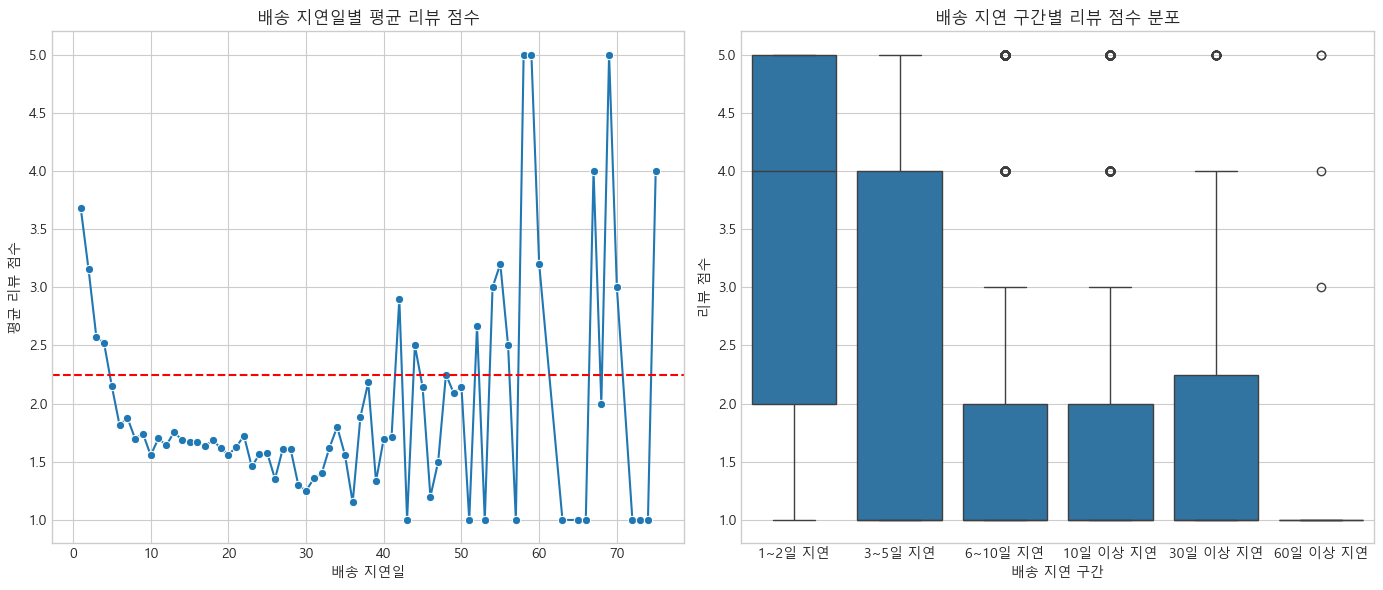

In [14]:
# 배송 지연일별 평균 리뷰
delay_review = df.groupby('delivery_delay_days')['review_score'].mean().reset_index()

# 배송 지연 구간 생성
bins = [1,3,6,11,31,61, df['delivery_delay_days'].max()]
labels = ['1~2일 지연','3~5일 지연','6~10일 지연','10일 이상 지연', '30일 이상 지연', '60일 이상 지연']

df['delay_group'] = pd.cut(
    df['delivery_delay_days'],
    bins=bins,
    labels=labels,
    right=False
)

# 시각화
fig, axes = plt.subplots(1,2, figsize=(14,6))

# 1. 배송 지연일별 평균 리뷰
sns.lineplot(
    data=delay_review,
    x='delivery_delay_days',
    y='review_score',
    marker='o',
    ax=axes[0]
)

axes[0].axhline(df['review_score'].mean(), linestyle='--', color='red')
axes[0].set_title("배송 지연일별 평균 리뷰 점수")
axes[0].set_xlabel("배송 지연일")
axes[0].set_ylabel("평균 리뷰 점수")

# 2. 배송 지연 구간별 리뷰
sns.boxplot(
    data=df,
    x='delay_group',
    y='review_score',
    ax=axes[1]
)

axes[1].set_title("배송 지연 구간별 리뷰 점수 분포")
axes[1].set_xlabel("배송 지연 구간")
axes[1].set_ylabel("리뷰 점수")

plt.tight_layout()
plt.show()


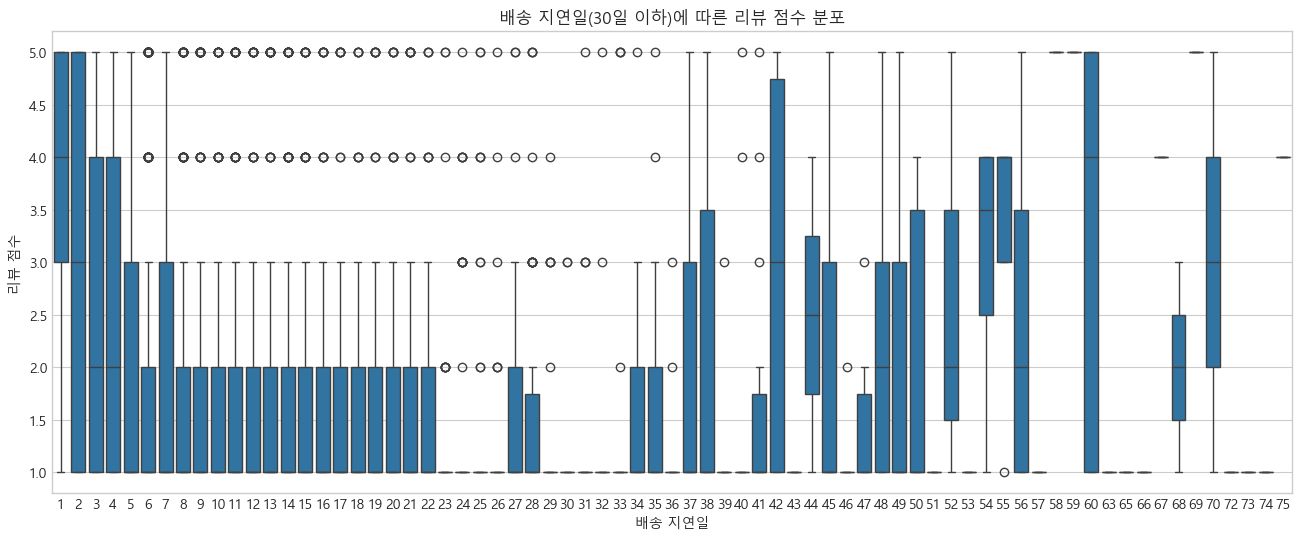

In [15]:
# 배송 지연일 & 리뷰 분포 

plt.figure(figsize=(16,6))
sns.boxplot(
    data=df,
    x='delivery_delay_days',
    y='review_score'
)

plt.title("배송 지연일(30일 이하)에 따른 리뷰 점수 분포")
plt.xlabel("배송 지연일")
plt.ylabel("리뷰 점수")

plt.show()


In [16]:
from scipy import stats
import scikit_posthocs as sp

# NaN 값 제거 
df_test = df.dropna(subset=['delay_group']).copy()

# 각 지연 구간별 그룹 데이터 준비
group1 = df_test[df_test['delay_group'] == '1~2일 지연']['review_score']
group2 = df_test[df_test['delay_group'] == '3~5일 지연']['review_score']
group3 = df_test[df_test['delay_group'] == '6~10일 지연']['review_score']
group4 = df_test[df_test['delay_group'] == '10일 이상 지연']['review_score']
group5 = df_test[df_test['delay_group'] == '30일 이상 지연']['review_score']
group6 = df_test[df_test['delay_group'] == '60일 이상 지연']['review_score']

# 분석에 사용된 데이터: 7,011개 행

# 각 그룹의 표본 크기
#   1~2일 지연: 1,519개
#   3~5일 지연: 1,532개
#   6~10일 지연: 1,806개
#   10일 이상 지연: 1,869개
#   - 30일 이상 지연: 268개
#   - 60일 이상 지연: 17개

# Kruskal-Wallis 검정 
# 귀무가설: 모든 그룹의 분포가 같다
# 대립가설: 적어도 하나의 그룹 분포가 다르다
h_stat, kw_p_val = stats.kruskal(group1, group2, group3, group4, group5, group6)



print(f"검정 통계량: {h_stat:.4f}")
print(f"P-value: {kw_p_val:.2e}")

if kw_p_val < 0.05:
    print("결론: 배송 지연 구간별로 리뷰 점수에 통계적으로 유의미한 차이가 있다. (p < 0.05)")
else:
    print("결론: 배송 지연 구간별로 리뷰 점수에 통계적으로 유의미한 차이가 없다. (p ≥ 0.05)")
print()


검정 통계량: 1362.7742
P-value: 1.60e-292
결론: 배송 지연 구간별로 리뷰 점수에 통계적으로 유의미한 차이가 있다. (p < 0.05)



In [17]:
# Dunn 사후 검정
# Kruskal-Wallis 검정에서 유의미한 차이 O

posthoc = sp.posthoc_dunn(df_test, val_col='review_score', group_col='delay_group', p_adjust='bonferroni')
print(posthoc)
print()

# p값이 0.05 미만인 쌍
print("유의미한 차이 있는 그룹 쌍:")
significant_pairs = []
for i in range(len(posthoc.columns)):
    for j in range(i+1, len(posthoc.columns)):
        if posthoc.iloc[i, j] < 0.05:
            group_i = posthoc.columns[i]
            group_j = posthoc.columns[j]
            p_value = posthoc.iloc[i, j]
            significant_pairs.append((group_i, group_j, p_value))
            print(f"{group_i} vs {group_j}: p = {p_value:.4f}")

if not significant_pairs:
    print("유의미한 차이 있는 쌍이 없다.")



                 1~2일 지연       3~5일 지연       6~10일 지연      10일 이상 지연  \
1~2일 지연     1.000000e+00  2.153676e-73  7.907218e-205  1.703161e-238   
3~5일 지연     2.153676e-73  1.000000e+00   3.335143e-30   5.243407e-43   
6~10일 지연   7.907218e-205  3.335143e-30   1.000000e+00   3.247793e-01   
10일 이상 지연  1.703161e-238  5.243407e-43   3.247793e-01   1.000000e+00   
30일 이상 지연   7.227312e-58  7.359158e-09   1.000000e+00   1.000000e+00   
60일 이상 지연   4.964447e-05  7.888556e-01   1.000000e+00   1.000000e+00   

              30일 이상 지연  60일 이상 지연  
1~2일 지연    7.227312e-58   0.000050  
3~5일 지연    7.359158e-09   0.788856  
6~10일 지연   1.000000e+00   1.000000  
10일 이상 지연  1.000000e+00   1.000000  
30일 이상 지연  1.000000e+00   1.000000  
60일 이상 지연  1.000000e+00   1.000000  

유의미한 차이 있는 그룹 쌍:
1~2일 지연 vs 3~5일 지연: p = 0.0000
1~2일 지연 vs 6~10일 지연: p = 0.0000
1~2일 지연 vs 10일 이상 지연: p = 0.0000
1~2일 지연 vs 30일 이상 지연: p = 0.0000
1~2일 지연 vs 60일 이상 지연: p = 0.0000
3~5일 지연 vs 6~10일 지연: p = 0.0000
3~5일 지연 vs 10일 이상 지연: p 

In [18]:
#t-test 비교
from scipy import stats

results = []

for threshold in range(0, 76):
    group1 = df[df['delivery_delay_days'] <= threshold]['review_score'] # 0~N일
    group2 = df[df['delivery_delay_days'] > threshold]['review_score']  # N+일
    
    if len(group1) > 1 and len(group2) > 1:
        t_stat, p_val = stats.ttest_ind(group1, group2)
        results.append({
            'threshold': threshold,
            'group1_mean': group1.mean(),
            'group2_mean': group2.mean(),
            'mean_diff': abs(group1.mean() - group2.mean()),
            'p_val': p_val
        })

results_df = pd.DataFrame(results)
#results_df
#결과해석 : p값이 0.05 미만이면 배송지연이 " "일 이상이면 리뷰 점수가 유의미하게 떨어진다는 의미!

In [19]:
# 최적 임계값 찾기 (2가지 방법)

# 평균 차이가 가장 큰 임계값
best_mean_diff = results_df.loc[results_df['mean_diff'].idxmax()]
# print(f"임계값: {int(best_mean_diff['threshold'])}일")
# print(f"평균 차이: {best_mean_diff['mean_diff']:.3f}점")
# print(f"p값: {best_mean_diff['p_val']:.2e}")
# print('')

# p값이 가장 작은 임계값 (가장 유의미)
best_p_val = results_df.loc[results_df['p_val'].idxmin()]
# print(f"임계값: {int(best_p_val['threshold'])}일")
# print(f"평균 차이: {best_p_val['mean_diff']:.3f}점")
# print(f"p값: {best_p_val['p_val']:.2e}")


#======================================================================================

# 결과
# 평균차가 가장 큰 임계값
#   임계값: 1일
#   평균 차이: 1.649점
#   p값: 4.73e-209

# p값이 가장 작은 임계값
#   임계값: 2일
#   평균 차이: 1.566점
#   p값: 2.95e-284

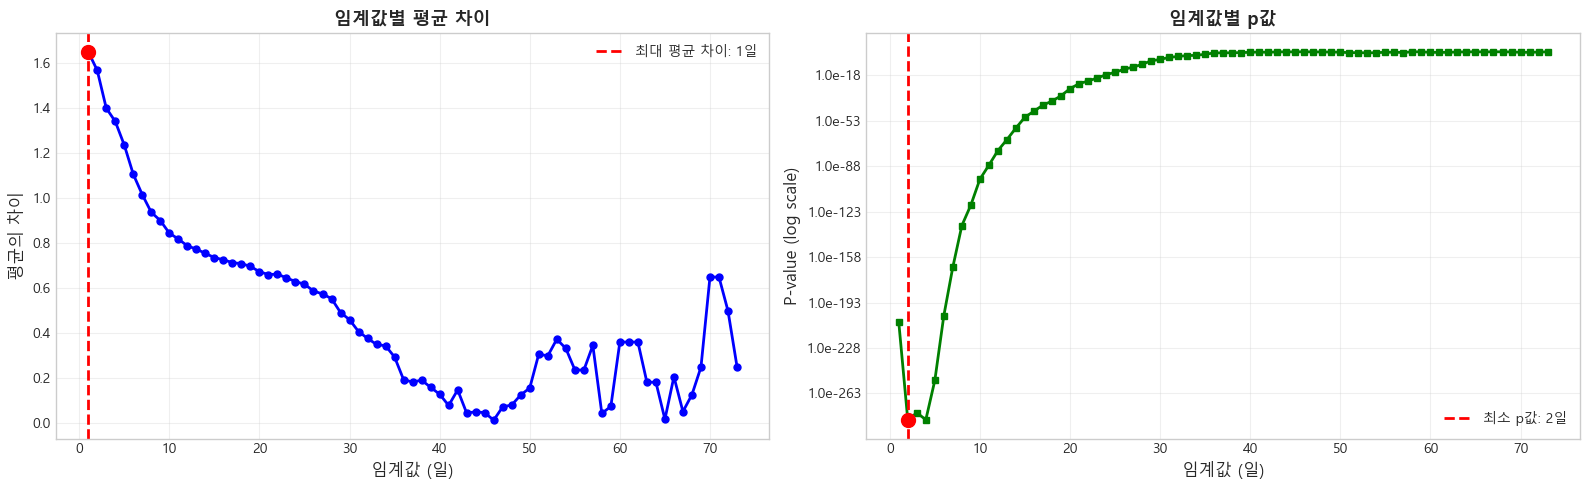

In [20]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt

def format_sci(x, pos):
    """지수 표기법을 마이너스 기호 없이 포맷"""
    if x == 0:
        return '0'
    s = f'{x:.1e}'
    parts = s.split('e')
    mantissa = parts[0]
    exponent = parts[1]
    exp_num = int(exponent)
    return f'{float(mantissa):.1f}e{exp_num}'



# 비교 시각화
best_mean_diff = results_df.loc[results_df['mean_diff'].idxmax()]
threshold_1 = int(best_mean_diff['threshold'])
mean_diff_1 = best_mean_diff['mean_diff']
p_val_1 = best_mean_diff['p_val']

best_p_val = results_df.loc[results_df['p_val'].idxmin()]
threshold_2 = int(best_p_val['threshold'])
mean_diff_2 = best_p_val['mean_diff']
p_val_2 = best_p_val['p_val']


fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 평균 차이 변화
axes[0].plot(results_df['threshold'], results_df['mean_diff'], marker='o', linewidth=2, markersize=5, color='blue')
axes[0].axvline(threshold_1, color='red', linestyle='--', linewidth=2, label=f'최대 평균 차이: {threshold_1}일')
axes[0].scatter([threshold_1], [mean_diff_1], color='red', s=100, zorder=5)
axes[0].set_xlabel('임계값 (일)', fontsize=12)
axes[0].set_ylabel('평균의 차이', fontsize=12)
axes[0].set_title('임계값별 평균 차이', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].legend()

# p값 변화
axes[1].semilogy(results_df['threshold'], results_df['p_val'], marker='s', linewidth=2, markersize=5, color='green')
axes[1].axvline(threshold_2, color='red', linestyle='--', linewidth=2, label=f'최소 p값: {threshold_2}일')
axes[1].scatter([threshold_2], [p_val_2], color='red', s=100, zorder=5)
axes[1].set_xlabel('임계값 (일)', fontsize=12)
axes[1].set_ylabel('P-value (log scale)', fontsize=12)
axes[1].set_title('임계값별 p값', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3, which='both')
axes[1].yaxis.set_major_formatter(FuncFormatter(format_sci))
axes[1].legend()

plt.tight_layout()
plt.show()



In [21]:
# 임계값 최종 결정(p값이 가장 작은 임계값)
best_threshold = int(best_p_val['threshold'])
best_threshold

2

In [22]:
# Elbow Method 

inertias = []
threshold_list = np.arange(0, 76, 1)  #임의 지정

#분산 계산
for threshold in threshold_list:
    group1 = df[df['delivery_delay_days'] <= threshold]['review_score']
    group2 = df[df['delivery_delay_days'] > threshold]['review_score']
    
    if len(group1) > 1 and len(group2) > 1:
        inertia = group1.var() * len(group1) + group2.var() * len(group2)
        inertias.append(inertia)
        
        #print(f"임계값 {threshold:.1f}일: 분산 = {inertia:.2f}")
    else:
        inertias.append(np.nan)
inertias = np.array(inertias)

#기울기 변화 
# 1차 미분 (기울기)
slopes = np.diff(inertias)

# 2차 미분 (기울기의 변화)
second_derivative = np.diff(slopes)

#elbow 찾기
# 기울기가 가장 급격하게 변하는 지점이자 분산이 가장 크게 줄어드는 지점
elbow_idx = np.nanargmax(np.abs(second_derivative)) + 1
elbow_threshold = threshold_list[elbow_idx]

print(f"최적 임계값 (Elbow): {elbow_threshold:.1f}일")
print(f"(최대 2차 미분 값: {np.abs(second_derivative[elbow_idx-1]):.2f})")

# 두 그룹 정보 출력
group1_elbow = df[df['delivery_delay_days'] <= elbow_threshold]['review_score']
group2_elbow = df[df['delivery_delay_days'] > elbow_threshold]['review_score']


최적 임계값 (Elbow): 2.0일
(최대 2차 미분 값: 780.30)


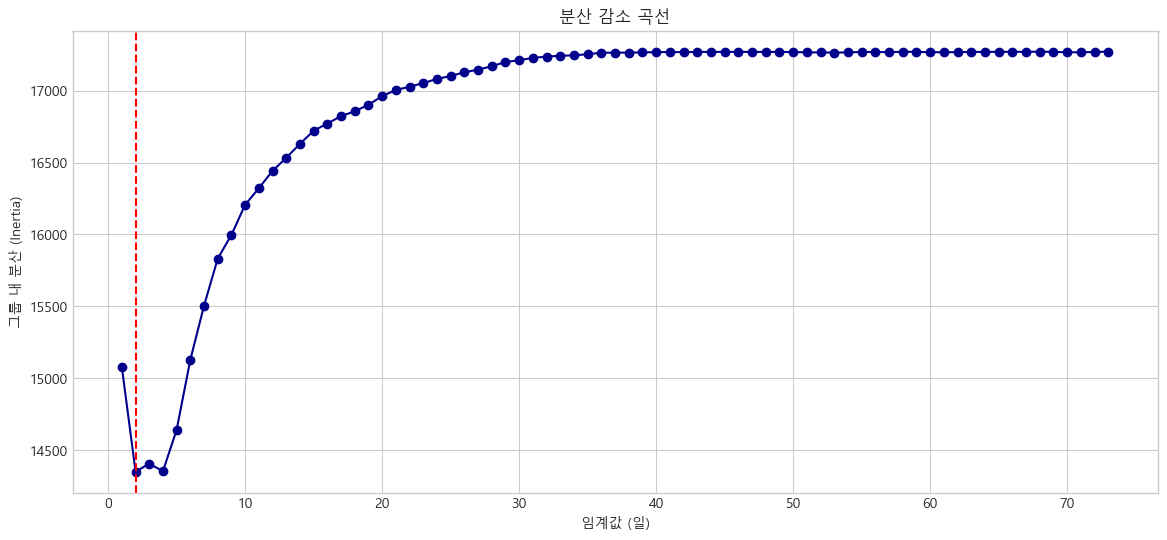

In [23]:
# 시각화 _분산 곡선 (Inertia)

plt.figure(figsize=(14,6))

plt.plot(
    threshold_list,
    inertias,
    marker='o',
    color='darkblue'
)

plt.axvline(
    x=elbow_threshold,
    color='red',
    linestyle='--'
)

plt.xlabel('임계값 (일)')
plt.ylabel('그룹 내 분산 (Inertia)')
plt.title('분산 감소 곡선')

plt.show()


# 최적 임계값: 2일
# 2일을 기준으로 그룹을 나누면 그룹 내 분산이 가장 크게 줄어듦
# 즉, 두 그룹이 가장 잘 분리됨
# 배송 지연 2일 기준으로 리뷰 평가 패턴이 달라질 가능성이 있음
